In [59]:
import pandas as pd

In [60]:
import matplotlib.pyplot as plt

def show_plot(df, region):
    
    df_s1 = df[df['Sektor_ID'] == 'S_1'].copy()

    df_s1['Data'] = pd.to_datetime(df_s1['Data'])
    df_s1 = df_s1.sort_values('Data')

    plt.figure(figsize=(12, 6))

    plt.plot(df_s1['Data'], df_s1['NDVI'], marker='o', label='NDVI', color='green')
    plt.plot(df_s1['Data'], df_s1['NDWI'], marker='o', label='NDWI', color='blue')
    plt.plot(df_s1['Data'], df_s1['NDMI'], marker='o', label='NDMI', color='teal')

    plt.title(f"Satellite Indices Time-Series Analysis - Sector S_1 ({region})", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Indicator", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

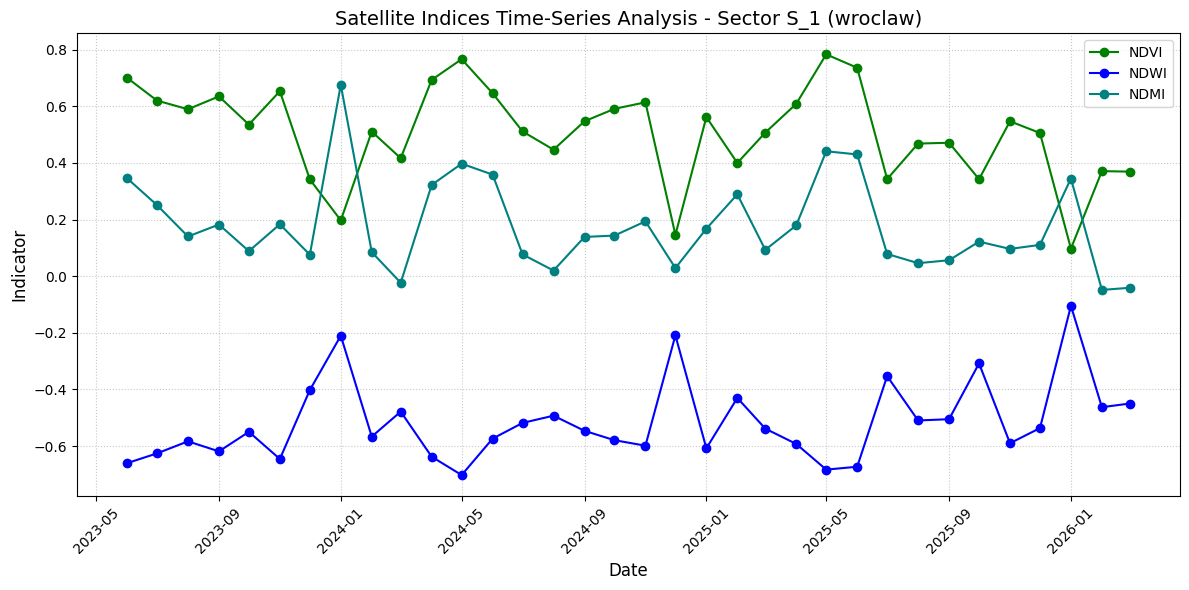

In [61]:
REGION = "wroclaw"

df = pd.read_csv(f"../data/{REGION}/raw.csv")
df['Data'] = pd.to_datetime(df['Data'])
df = df.sort_values(by=["Sektor_ID", "Data"]).reset_index(drop=True)


df.head()

show_plot(df, REGION)

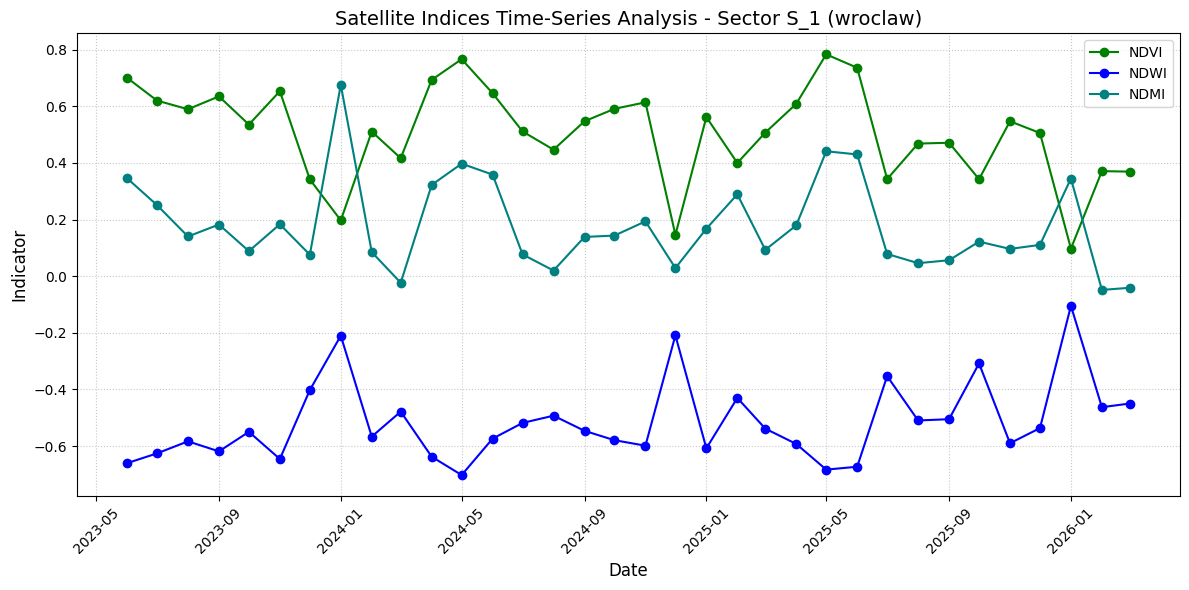

In [62]:
df = df.sort_values(by=["Sektor_ID", "Data"]).reset_index(drop=True)

indicators = ['NDVI', 'NDWI', 'NDMI']

df[indicators ] = df.groupby('Sektor_ID')[indicators ].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

df.head()

show_plot(df, REGION)

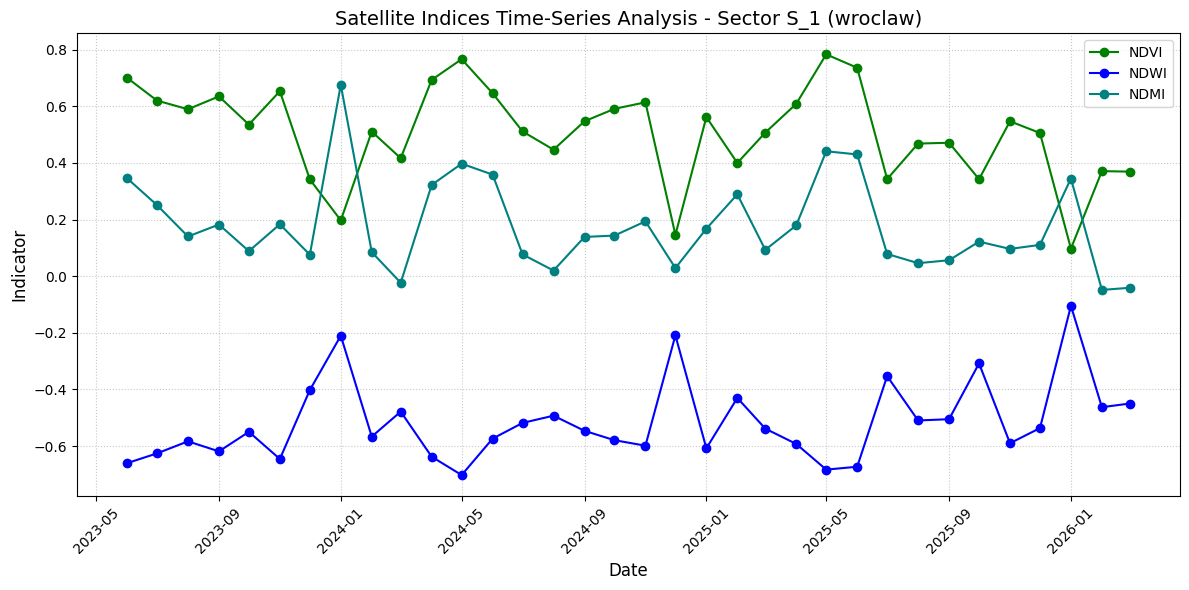

In [63]:
#df[indicators] = df.groupby('Sektor_ID')[indicators].transform(
#    lambda x: x.ewm(span=3, adjust=False).mean()
#)

show_plot(df, REGION)

In [64]:
df = df.round(4)
df.head()

C:\Users\LG\Desktop\TEMP\ipykernel_4868\4019073279.py:1: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df = df.round(4)


,Sektor_ID,Lat,Lon,Data,NDVI,NDWI,NDMI
0,S_1,50.96,16.71,2023-06-01,0.7008,-0.6606,0.3460
1,S_1,50.96,16.71,2023-07-01,0.6203,-0.6261,0.2510
2,S_1,50.96,16.71,2023-08-01,0.5897,-0.5835,0.1402
3,S_1,50.96,16.71,2023-09-01,0.6351,-0.6190,0.1824
4,S_1,50.96,16.71,2023-10-01,0.5356,-0.5500,0.0885


In [65]:
df.to_csv(f"../data/{REGION}/clean.csv", index=False)